# CO2 Emissions Forecasting (R3)

This notebook implements **R3 only** from `Fix.md`:
1. Time-aware forecasting setup
2. Feature engineering (lags and rolling trends)
3. Baselines (Linear, Ridge, Lasso)
4. Tree models (Random Forest, XGBoost if available)
5. Deep learning (MLP, LSTM if TensorFlow is available)
6. Optional Hugging Face pretrained model check
7. Ensemble and final comparison


In [27]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# -----------------------------
# Runtime / CUDA setup (first)
# -----------------------------
# We detect CUDA as early as possible so later model cells can decide whether
# to use GPU backends when supported.
HAS_TORCH = False
HAS_CUDA = False
CUDA_DEVICE_NAME = 'None'
DEVICE = 'cpu'

try:
    import torch

    HAS_TORCH = True
    HAS_CUDA = torch.cuda.is_available()
    DEVICE = 'cuda' if HAS_CUDA else 'cpu'
    if HAS_CUDA:
        CUDA_DEVICE_NAME = torch.cuda.get_device_name(0)
except Exception as e:
    torch = None
    print('PyTorch not available:', e)

print('PyTorch available:', HAS_TORCH)
print('CUDA available:', HAS_CUDA)
print('CUDA device:', CUDA_DEVICE_NAME)
print('Default torch device:', DEVICE)

# TensorFlow is optional; if present, it can also use CUDA automatically.
HAS_TF = False
TF_BUILT_WITH_CUDA = False
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers

    HAS_TF = True
    TF_BUILT_WITH_CUDA = bool(tf.test.is_built_with_cuda())
    tf_gpus = tf.config.list_physical_devices('GPU')
    print('TensorFlow built with CUDA:', TF_BUILT_WITH_CUDA)
    print('TensorFlow GPUs detected:', tf_gpus)

    # Keep VRAM allocation dynamic instead of grabbing all memory at startup.
    for gpu in tf_gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception:
            pass

    if len(tf_gpus) == 0:
        print('TensorFlow will run on CPU (no TF-visible GPU).')
except Exception as e:
    tf = None
    keras = None
    layers = None
    print('TensorFlow not available:', e)


from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Paths are aligned with the existing project convention.
DATA_PATH = Path('cleaned_co2_data_20vars.csv')
OUTPUT_DIR = Path('output_r3')
OUTPUT_DIR.mkdir(exist_ok=True)
(OUTPUT_DIR / 'figures').mkdir(exist_ok=True)
(OUTPUT_DIR / 'tables').mkdir(exist_ok=True)

TARGET = 'co2_per_capita'
ID_COLS = ['country', 'year', 'iso_code']

# We keep a stable base set and only use columns that are actually present.
BASE_FEATURES = [
    'population', 'gdp', 'primary_energy_consumption',
    'energy_per_capita', 'energy_per_gdp',
    'co2', 'total_ghg', 'consumption_co2',
    'coal_co2', 'gas_co2', 'oil_co2'
]


def plot_pred_vs_actual(y_true, y_pred, model_name, suffix='test'):
    """
    Plot predicted vs actual values for one model and save to disk.

    Why this helper exists:
    - We want a consistent diagnostic plot after each model block.
    - Using one helper avoids copy-paste and keeps figure style uniform.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    plt.figure(figsize=(5.5, 5.5))
    plt.scatter(y_true, y_pred, alpha=0.35)
    mn, mx = float(np.nanmin(y_true)), float(np.nanmax(y_true))
    plt.plot([mn, mx], [mn, mx], 'r--', lw=1)
    plt.xlabel('Actual co2_per_capita')
    plt.ylabel(f'Predicted ({model_name})')
    plt.title(f'{model_name}: Actual vs Predicted ({suffix})')
    plt.tight_layout()

    safe_name = model_name.lower().replace('(', '_').replace(')', '_').replace('+', '_').replace(' ', '_')
    out_path = OUTPUT_DIR / 'figures' / f'r3_{safe_name}_{suffix}_pred_vs_actual.png'
    plt.savefig(out_path, dpi=140)
    plt.show()


PyTorch available: True
CUDA available: True
CUDA device: NVIDIA GeForce RTX 5060 Laptop GPU
Default torch device: cuda
TensorFlow built with CUDA: True
TensorFlow GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Load data and build time-aware features


In [28]:
# Read and sort first so all lag features are computed in the correct temporal order.
df = pd.read_csv(DATA_PATH)
df = df.sort_values(['country', 'year']).reset_index(drop=True)

# Keep only available base features to avoid hard failures if schema changed.
base_features = [c for c in BASE_FEATURES if c in df.columns]
print('Data shape:', df.shape)
print('Year range:', df['year'].min(), '-', df['year'].max())
print('Base features used:', len(base_features))

# Country-wise lag features directly follow the R3 requirement in Fix.md.
g = df.groupby('country')
df['co2_lag1'] = g[TARGET].shift(1)
df['co2_lag3'] = g[TARGET].shift(3)

if 'gdp' in df.columns:
    df['gdp_lag1'] = g['gdp'].shift(1)
if 'energy_per_capita' in df.columns:
    df['energy_lag1'] = g['energy_per_capita'].shift(1)

# Rolling trend features summarize short-term history and reduce noise.
df['co2_roll3_mean'] = g[TARGET].rolling(window=3, min_periods=2).mean().reset_index(level=0, drop=True)
df['co2_roll5_mean'] = g[TARGET].rolling(window=5, min_periods=3).mean().reset_index(level=0, drop=True)

# First rows per country have NaN due to lag/rolling by design; we drop only after feature creation.
feature_cols = [c for c in df.columns if c not in ID_COLS + [TARGET]]
model_df = df[ID_COLS + [TARGET] + feature_cols].dropna().copy()

print('Modeling rows after lag/rolling:', model_df.shape)


Data shape: (2640, 20)
Year range: 1990 - 2022
Base features used: 11
Modeling rows after lag/rolling: (2368, 26)


In [29]:
# Time-based split (not random) to respect forecasting chronology.
train = model_df[(model_df['year'] >= 1990) & (model_df['year'] <= 2015)].copy()
val = model_df[(model_df['year'] >= 2016) & (model_df['year'] <= 2019)].copy()
test = model_df[(model_df['year'] >= 2020) & (model_df['year'] <= 2022)].copy()

predictor_cols = [c for c in feature_cols if c in train.columns]

print(f'Train: {len(train)} | Val: {len(val)} | Test: {len(test)}')
print('Predictor count:', len(predictor_cols))

# Standardize for linear models and neural networks.
scaler = StandardScaler()
X_train = scaler.fit_transform(train[predictor_cols])
X_val = scaler.transform(val[predictor_cols])
X_test = scaler.transform(test[predictor_cols])

y_train = train[TARGET].to_numpy()
y_val = val[TARGET].to_numpy()
y_test = test[TARGET].to_numpy()

# Tree models often work well without scaling, so we keep raw matrices too.
X_train_raw = train[predictor_cols].to_numpy()
X_val_raw = val[predictor_cols].to_numpy()
X_test_raw = test[predictor_cols].to_numpy()


Train: 1756 | Val: 346 | Test: 266
Predictor count: 22


In [30]:
def evaluate(y_true, y_pred):
    """
    Compute the full regression metric set used across all R3 models.

    What this function does:
    1) Converts inputs to numpy arrays for consistent math behavior.
    2) Computes RMSE to penalize larger errors more strongly.
    3) Computes MAE for easy-to-interpret average absolute error.
    4) Computes R2 to measure explained variance quality.
    5) Computes MAPE with zero-safe handling to avoid divide-by-zero crashes.

    Returning a single dictionary keeps every model comparison table consistent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # MAPE can explode when y_true is 0; we replace near-zero denominators with NaN
    # so they are ignored in the average rather than causing inf values.
    denom = np.where(np.abs(y_true) < 1e-8, np.nan, np.abs(y_true))
    mape = np.nanmean(np.abs((y_true - y_pred) / denom)) * 100

    return {
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'R2': float(r2_score(y_true, y_pred)),
        'MAPE': float(mape) if not np.isnan(mape) else np.nan,
    }


## 2. Baseline models (Linear, Ridge, Lasso)


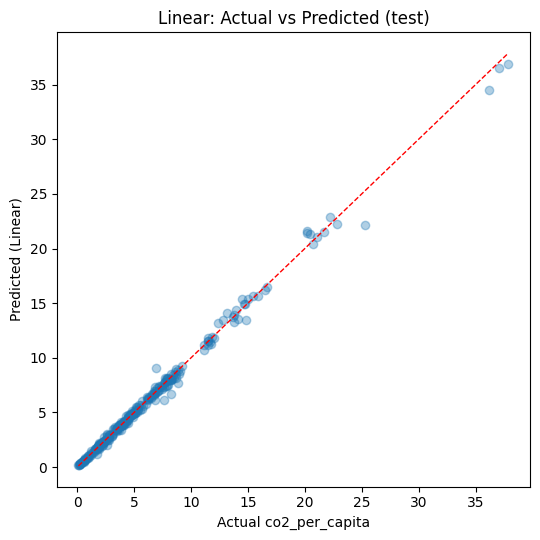

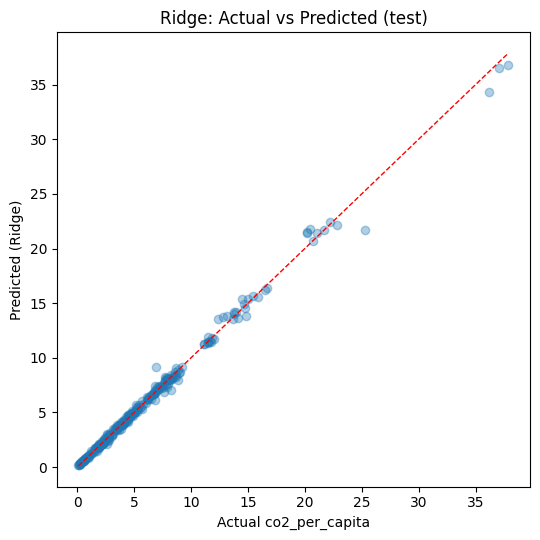

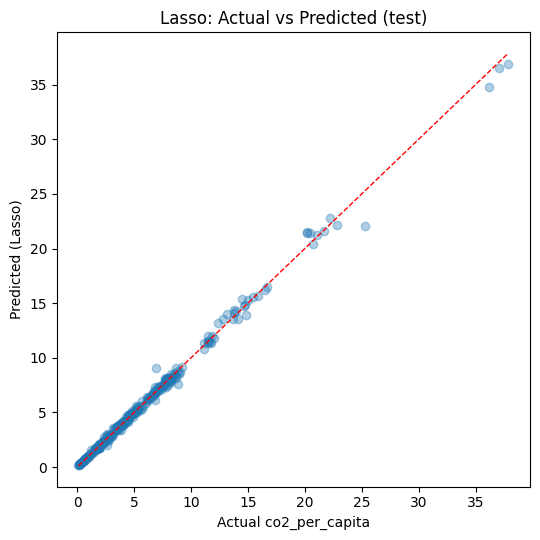

,Model,Val_RMSE,Val_MAE,Val_R2,Val_MAPE,Test_RMSE,Test_MAE,Test_R2,Test_MAPE
0,Linear,0.338854,0.165248,0.996896,3.669538,0.405592,0.223739,0.995014,5.191083
1,Ridge,0.339939,0.167396,0.996876,3.982470,0.407698,0.213303,0.994962,5.271933
2,Lasso,0.340539,0.160270,0.996865,3.592337,0.376294,0.207412,0.995708,4.848228


In [31]:
preds = {}   # model_name -> np.array of test predictions (all aligned to y_test)
results = [] # list of metric dicts, one per model


def add_result(row):
    """
    Upsert a result row by model name.

    Why this matters:
    - Without this, re-running any cell without a full kernel restart
      appends duplicate rows (e.g. two TimesFM rows) which corrupts the
      final comparison table and ruins the ensemble selection.
    - Using upsert ensures each model always has exactly one entry.
    """
    global results
    results = [r for r in results if r.get('Model') != row.get('Model')]
    results.append(row)


baseline_models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001, max_iter=5000),
}

# Note: sklearn linear-family models are CPU implementations.
# They do not have native CUDA training paths.
for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    pred_val = model.predict(X_val)
    pred_test = model.predict(X_test)
    preds[name] = pred_test

    row = {'Model': name}
    row.update({f'Val_{k}': v for k, v in evaluate(y_val, pred_val).items()})
    row.update({f'Test_{k}': v for k, v in evaluate(y_test, pred_test).items()})
    add_result(row)

    plot_pred_vs_actual(y_test, pred_test, name, suffix='test')

pd.DataFrame(results)


## 3. Tree-based models (Random Forest, XGBoost)


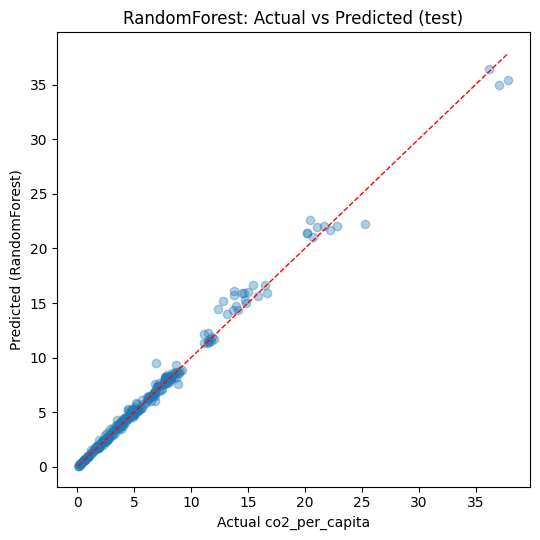

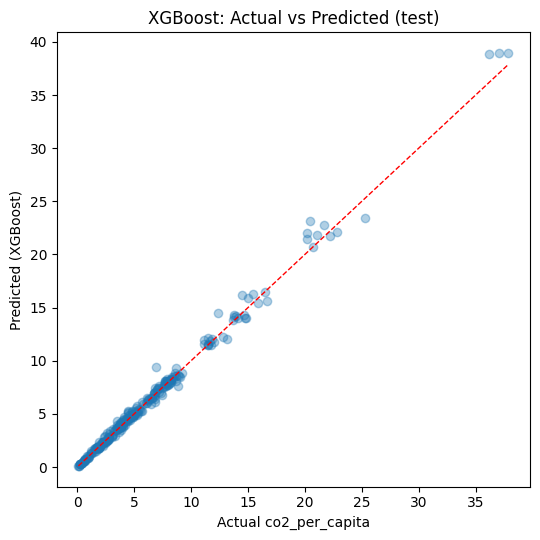

,Model,Val_RMSE,Val_MAE,Val_R2,Val_MAPE,Test_RMSE,Test_MAE,Test_R2,Test_MAPE
0,Linear,0.338854,0.165248,0.996896,3.669538,0.405592,0.223739,0.995014,5.191083
1,Ridge,0.339939,0.167396,0.996876,3.982470,0.407698,0.213303,0.994962,5.271933
2,Lasso,0.340539,0.160270,0.996865,3.592337,0.376294,0.207412,0.995708,4.848228
3,RandomForest,0.540665,0.222113,0.992098,3.813645,0.552790,0.298929,0.990738,5.348712
4,XGBoost,0.475590,0.218470,0.993885,3.826853,0.502130,0.282905,0.992358,5.367664


In [32]:
# Random Forest is a robust non-linear baseline.
# Note: sklearn RandomForest is CPU-only.
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train_raw, y_train)
preds['RandomForest'] = rf.predict(X_test_raw)

row_rf = {'Model': 'RandomForest'}
row_rf.update({f'Val_{k}': v for k, v in evaluate(y_val, rf.predict(X_val_raw)).items()})
row_rf.update({f'Test_{k}': v for k, v in evaluate(y_test, preds['RandomForest']).items()})
add_result(row_rf)
plot_pred_vs_actual(y_test, preds['RandomForest'], 'RandomForest', suffix='test')

# XGBoost can use CUDA if available.
try:
    from xgboost import XGBRegressor

    xgb_kwargs = {
        'n_estimators': 500,
        'learning_rate': 0.03,
        'max_depth': 6,
        'subsample': 0.9,
        'colsample_bytree': 0.8,
        'objective': 'reg:squarederror',
        'random_state': 42,
    }

    # Recent xgboost versions support device='cuda'.
    # Older ones may require tree_method='gpu_hist'.
    if HAS_CUDA:
        xgb_kwargs.update({'device': 'cuda', 'tree_method': 'hist'})

    xgb = XGBRegressor(**xgb_kwargs)
    xgb.fit(X_train_raw, y_train)
    preds['XGBoost'] = xgb.predict(X_test_raw)

    row_xgb = {'Model': 'XGBoost'}
    row_xgb.update({f'Val_{k}': v for k, v in evaluate(y_val, xgb.predict(X_val_raw)).items()})
    row_xgb.update({f'Test_{k}': v for k, v in evaluate(y_test, preds['XGBoost']).items()})
    add_result(row_xgb)
    plot_pred_vs_actual(y_test, preds['XGBoost'], 'XGBoost', suffix='test')
except Exception as e:
    print('XGBoost skipped:', e)

pd.DataFrame(results)


## 4. Neural network baseline (MLP)


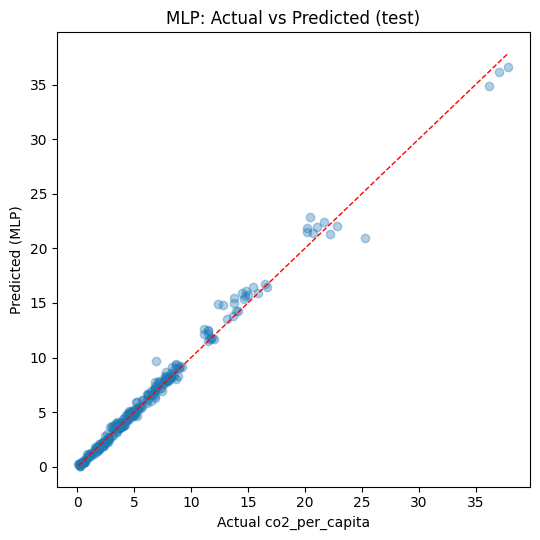

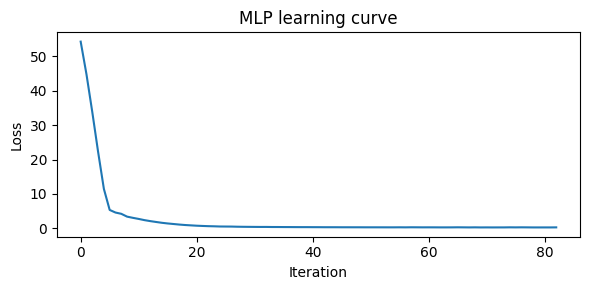

,Model,Val_RMSE,Val_MAE,Val_R2,Val_MAPE,Test_RMSE,Test_MAE,Test_R2,Test_MAPE
0,Linear,0.338854,0.165248,0.996896,3.669538,0.405592,0.223739,0.995014,5.191083
1,Ridge,0.339939,0.167396,0.996876,3.982470,0.407698,0.213303,0.994962,5.271933
2,Lasso,0.340539,0.160270,0.996865,3.592337,0.376294,0.207412,0.995708,4.848228
3,RandomForest,0.540665,0.222113,0.992098,3.813645,0.552790,0.298929,0.990738,5.348712
4,XGBoost,0.475590,0.218470,0.993885,3.826853,0.502130,0.282905,0.992358,5.367664
5,MLP,0.495767,0.271895,0.993356,7.207119,0.583851,0.346628,0.989668,8.869332


In [33]:
# MLP provides a non-linear baseline without sequence structure.
# Note: sklearn's MLPRegressor is CPU-only.
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
)
mlp.fit(X_train, y_train)

preds['MLP'] = mlp.predict(X_test)
row_mlp = {'Model': 'MLP'}
row_mlp.update({f'Val_{k}': v for k, v in evaluate(y_val, mlp.predict(X_val)).items()})
row_mlp.update({f'Test_{k}': v for k, v in evaluate(y_test, preds['MLP']).items()})
add_result(row_mlp)

plot_pred_vs_actual(y_test, preds['MLP'], 'MLP', suffix='test')

if hasattr(mlp, 'loss_curve_'):
    plt.figure(figsize=(6, 3))
    plt.plot(mlp.loss_curve_)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('MLP learning curve')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'figures' / 'r3_mlp_learning_curve.png', dpi=150)
    plt.show()

pd.DataFrame(results)


## 5. Sequence model (LSTM)


LSTM train sequences: (1666, 5, 22)
LSTM test sequences: (256, 5, 22)


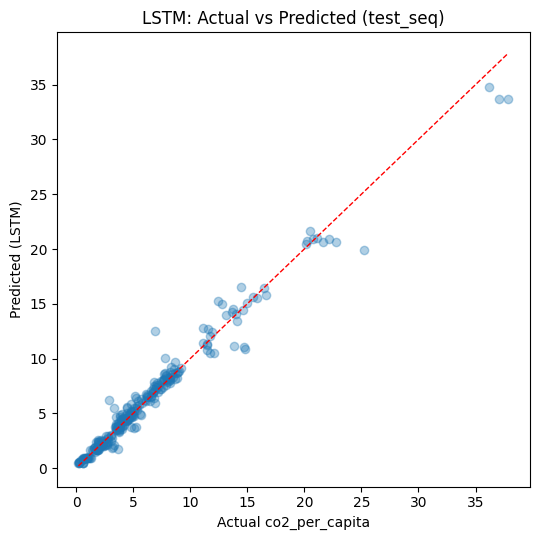

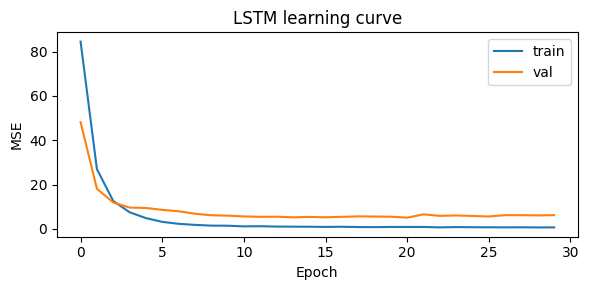

In [34]:
SEQ_LEN = 5

def build_sequences(frame, pred_cols, target_col, seq_len=5):
    """
    Convert panel data into LSTM-ready sliding windows.

    For each country independently:
    - X[i] contains `seq_len` historical timesteps
    - y[i] is the target at the next timestep
    """
    X_list, y_list = [], []
    for _, g in frame.sort_values(['country', 'year']).groupby('country'):
        g = g.sort_values('year')
        arr_x = g[pred_cols].to_numpy()
        arr_y = g[target_col].to_numpy()

        if len(g) <= seq_len:
            continue

        for i in range(seq_len, len(g)):
            X_list.append(arr_x[i - seq_len:i])
            y_list.append(arr_y[i])

    return np.array(X_list), np.array(y_list)


def build_test_sequences_with_history(history_frame, test_frame, pred_cols, target_col, seq_len=5):
    """
    Build test sequences using pre-test history as context.

    Why this is required:
    - If test only has years 2020-2022 and seq_len=5, test-alone has no windows.
    - We concatenate each country's history + test rows, then only keep windows
      whose target year is in the true test period.
    """
    X_list, y_list = [], []
    test_years = set(test_frame['year'].unique())
    combined = pd.concat([history_frame, test_frame], ignore_index=True)

    for _, g in combined.sort_values(['country', 'year']).groupby('country'):
        g = g.sort_values('year')
        arr_x = g[pred_cols].to_numpy()
        arr_y = g[target_col].to_numpy()
        arr_year = g['year'].to_numpy()

        if len(g) <= seq_len:
            continue

        for i in range(seq_len, len(g)):
            # Keep only labels that belong to test years.
            if arr_year[i] in test_years:
                X_list.append(arr_x[i - seq_len:i])
                y_list.append(arr_y[i])

    return np.array(X_list), np.array(y_list)


# Fit scaler on train+val years for stable sequence normalization.
train_full = pd.concat([train, val], ignore_index=True).copy()
train_full[predictor_cols] = scaler.fit_transform(train_full[predictor_cols])

test_scaled = test.copy()
test_scaled[predictor_cols] = scaler.transform(test_scaled[predictor_cols])

X_seq_train, y_seq_train = build_sequences(train_full, predictor_cols, TARGET, seq_len=SEQ_LEN)
X_seq_test, y_seq_test = build_test_sequences_with_history(
    history_frame=train_full,
    test_frame=test_scaled,
    pred_cols=predictor_cols,
    target_col=TARGET,
    seq_len=SEQ_LEN,
)

print('LSTM train sequences:', X_seq_train.shape)
print('LSTM test sequences:', X_seq_test.shape)

if not HAS_TF:
    print('LSTM skipped: TensorFlow is not available in this environment.')
elif len(X_seq_train) == 0:
    print('LSTM skipped: no training sequences were created.')
elif len(X_seq_test) == 0:
    print('LSTM skipped: no test sequences were created (check seq_len and split ranges).')
else:
    lstm = keras.Sequential([
        layers.Input(shape=(SEQ_LEN, len(predictor_cols))),
        layers.LSTM(64),
        layers.Dense(32, activation='relu'),
        layers.Dense(1),
    ])
    lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
    hist = lstm.fit(
        X_seq_train,
        y_seq_train,
        epochs=30,
        batch_size=32,
        validation_split=0.15,
        verbose=0,
    )

    preds['LSTM'] = lstm.predict(X_seq_test, verbose=0).flatten()
    row_lstm = {'Model': 'LSTM'}
    row_lstm.update({f'Val_{k}': np.nan for k in ['RMSE', 'MAE', 'R2', 'MAPE']})
    row_lstm.update({f'Test_{k}': v for k, v in evaluate(y_seq_test, preds['LSTM']).items()})
    # LSTM is excluded from ensemble: its predictions align with y_seq_test,
    # not y_test, so it cannot be naively averaged with other models.
    row_lstm['_seq_only'] = True
    add_result(row_lstm)

    plot_pred_vs_actual(y_seq_test, preds['LSTM'], 'LSTM', suffix='test_seq')

    plt.figure(figsize=(6, 3))
    plt.plot(hist.history['loss'], label='train')
    plt.plot(hist.history['val_loss'], label='val')
    plt.title('LSTM learning curve')
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'figures' / 'r3_lstm_learning_curve.png', dpi=150)
    plt.show()


## 6. Hugging Face pretrained models (PatchTST + TimesFM)


transformers: already installed
timesfm: already installed
HF context length (years): 27
HF forecast horizon (years): 3
HF using torch device: cuda


Loading weights: 0it [00:00, ?it/s]

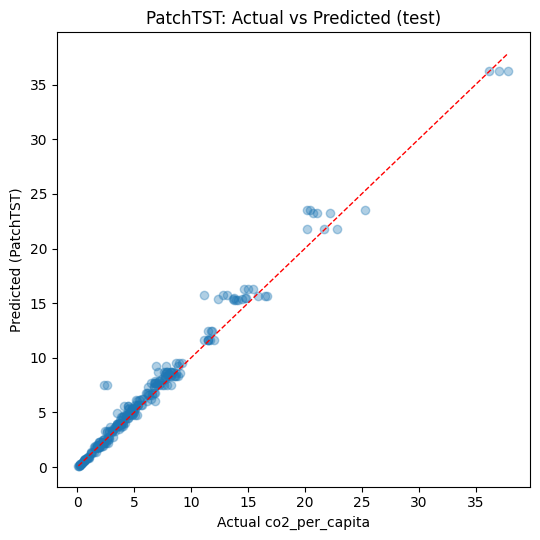

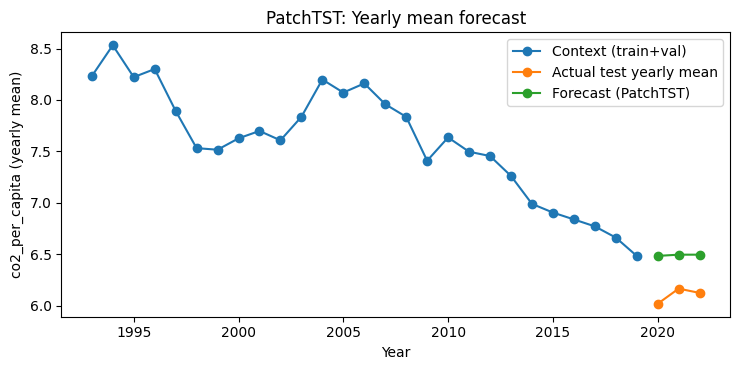

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

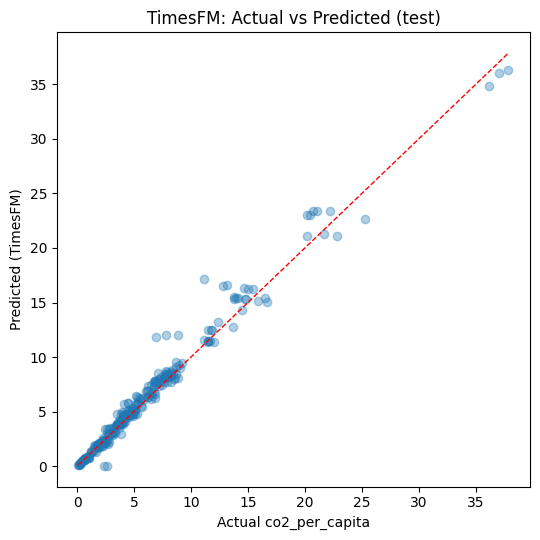

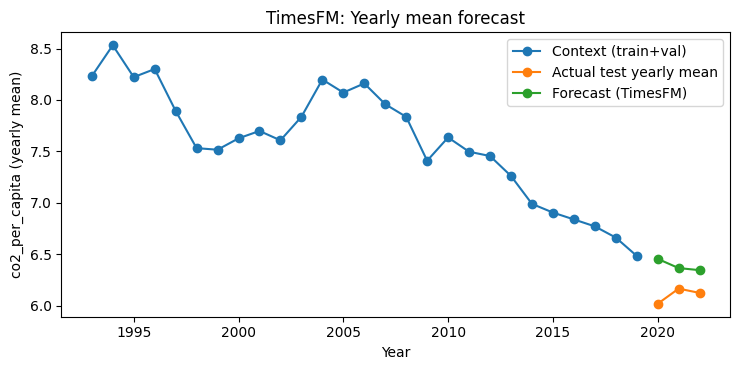

,Model,Status,Checkpoint
0,PatchTST,Success on cuda (fallback used for 89 countries),ibm/patchtst-etth1-pretrain
1,TimesFM,Success on gpu,google/timesfm-1.0-200m-pytorch


In [35]:
# This section implements two pretrained model attempts from Hugging Face ecosystem:
# 1) PatchTST (transformers)
# 2) TimesFM (google timesfm package with HF checkpoint)
#
# Improvement over previous version:
# - Forecast is done per-country (panel-aware), not one global yearly mean.
# - This prevents near-constant row predictions and gives more realistic scatter plots.

hf_rows = []


def ensure_package(pkg_name, import_name=None):
    """Ensure a package exists in the active notebook kernel."""
    import importlib
    import subprocess
    import sys

    import_name = import_name or pkg_name
    try:
        importlib.import_module(import_name)
        return True, 'already installed'
    except Exception:
        pass

    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg_name])
        importlib.import_module(import_name)
        return True, 'installed now'
    except Exception as e:
        return False, str(e)


ok_transformers, msg_transformers = ensure_package('transformers>=4.40', 'transformers')
ok_timesfm, msg_timesfm = ensure_package('timesfm', 'timesfm')
print('transformers:', msg_transformers)
print('timesfm:', msg_timesfm)


def extract_forecast_array(model_output):
    """Convert model outputs into a 1D numpy forecast robustly."""
    candidates = []
    for attr in ['prediction_outputs', 'predictions', 'sequences', 'forecast']:
        if hasattr(model_output, attr):
            candidates.append(getattr(model_output, attr))

    if isinstance(model_output, (tuple, list)) and len(model_output) > 0:
        candidates.append(model_output[0])

    for item in candidates:
        try:
            arr = item.detach().cpu().numpy() if hasattr(item, 'detach') else np.asarray(item)
            arr = np.asarray(arr)
            if arr.ndim == 3:
                return arr[0, :, 0]
            if arr.ndim == 2:
                return arr[0]
            if arr.ndim == 1:
                return arr
        except Exception:
            continue

    raise RuntimeError('Could not extract forecast array from model output.')


def normalize_context_series(series_values, target_len, patch_multiple=1):
    """Pad/truncate context so length is valid for model patching rules."""
    arr = np.asarray(series_values, dtype=np.float32).reshape(-1)
    if len(arr) == 0:
        arr = np.array([0.0], dtype=np.float32)

    target_len = int(max(1, target_len))
    if len(arr) < target_len:
        arr = np.pad(arr, (target_len - len(arr), 0), mode='edge')
    elif len(arr) > target_len:
        arr = arr[-target_len:]

    patch_multiple = int(max(1, patch_multiple))
    rem = len(arr) % patch_multiple
    if rem != 0:
        # Trim from left so we never exceed strict max context constraints.
        arr = arr[rem:]
        if len(arr) == 0:
            arr = np.array([float(series_values[-1])], dtype=np.float32)

    return arr


def align_horizon(pred, h):
    """Force any forecast array to exactly horizon h by pad/truncate."""
    pred = np.asarray(pred, dtype=np.float32).reshape(-1)
    if len(pred) == 0:
        return np.zeros(h, dtype=np.float32)
    if len(pred) < h:
        pred = np.pad(pred, (0, h - len(pred)), mode='edge')
    return pred[:h]


def plot_yearly_forecast(context_series, test_series, forecast_series, model_name):
    """Plot context, actual test yearly mean, and forecast yearly mean."""
    plt.figure(figsize=(7.5, 3.8))
    plt.plot(context_series.index, context_series.values, label='Context (train+val)', marker='o')
    plt.plot(test_series.index, test_series.values, label='Actual test yearly mean', marker='o')
    plt.plot(test_series.index, forecast_series, label=f'Forecast ({model_name})', marker='o')
    plt.title(f'{model_name}: Yearly mean forecast')
    plt.xlabel('Year')
    plt.ylabel('co2_per_capita (yearly mean)')
    plt.legend()
    plt.tight_layout()
    safe_name = model_name.lower().replace(' ', '_')
    plt.savefig(OUTPUT_DIR / 'figures' / f'r3_{safe_name}_yearly_forecast.png', dpi=140)
    plt.show()


# Reset test index to 0…N-1 so positional array assignment works correctly.
# Without this, test_eval retains original DataFrame indices (e.g. row 273),
# but patch_preds is sized len(test_eval), causing "index out of bounds".
test_eval = test.reset_index(drop=True).copy()
train_val = pd.concat([train, val], ignore_index=True)
train_val = train_val.sort_values(['country', 'year']).reset_index(drop=True)

# Build a dict: country -> list of positional (0-based) row indices in test_eval.
test_index_by_country = {
    c: g.index.to_numpy()
    for c, g in test_eval.groupby('country', sort=False)
}

print('HF context length (years):', train_val['year'].nunique())
print('HF forecast horizon (years):', test_eval['year'].nunique())
print('HF using torch device:', DEVICE)


# --------------------------
# PatchTST (Hugging Face)
# --------------------------
try:
    if not HAS_TORCH:
        raise RuntimeError('PyTorch is not available in this environment.')
    if not ok_transformers:
        raise RuntimeError('transformers package is unavailable after install attempt.')

    import inspect
    from transformers import PatchTSTForPrediction
    from transformers.utils import logging as hf_logging

    hf_logging.set_verbosity_error()

    patch_model = PatchTSTForPrediction.from_pretrained(
        'ibm/patchtst-etth1-pretrain',
        ignore_mismatched_sizes=True,
    ).to(DEVICE)
    patch_model.eval()

    cfg_context_len = int(getattr(patch_model.config, 'context_length', 64))
    cfg_patch_len = int(getattr(patch_model.config, 'patch_length', 1))
    forward_params = inspect.signature(patch_model.forward).parameters

    patch_preds = np.full(len(test_eval), np.nan, dtype=np.float32)
    patch_fail_count = 0

    for country, row_idx in test_index_by_country.items():
        hist = train_val.loc[train_val['country'] == country, TARGET].to_numpy(dtype=np.float32)
        h = len(row_idx)

        try:
            ctx = normalize_context_series(hist, target_len=cfg_context_len, patch_multiple=cfg_patch_len)
            context_tensor = torch.tensor(ctx, dtype=torch.float32, device=DEVICE).view(1, -1, 1)

            kwargs = {'past_values': context_tensor}
            if 'past_observed_mask' in forward_params:
                kwargs['past_observed_mask'] = torch.ones((1, context_tensor.shape[1]), dtype=torch.float32, device=DEVICE)

            with torch.no_grad():
                out = patch_model(**kwargs)

            pred_country = align_horizon(extract_forecast_array(out), h)
        except Exception:
            patch_fail_count += 1
            # Fallback: persistence forecast using latest known value for that country.
            last_val = float(hist[-1]) if len(hist) > 0 else float(np.nanmean(train_val[TARGET]))
            pred_country = np.full(h, last_val, dtype=np.float32)

        patch_preds[row_idx] = pred_country

    preds['PatchTST'] = patch_preds
    row_patch = {'Model': 'PatchTST'}
    row_patch.update({f'Val_{k}': np.nan for k in ['RMSE', 'MAE', 'R2', 'MAPE']})
    row_patch.update({f'Test_{k}': v for k, v in evaluate(y_test, patch_preds).items()})
    add_result(row_patch)

    status = f'Success on {DEVICE}'
    if patch_fail_count > 0:
        status += f' (fallback used for {patch_fail_count} countries)'
    hf_rows.append({'Model': 'PatchTST', 'Status': status, 'Checkpoint': 'ibm/patchtst-etth1-pretrain'})

    plot_pred_vs_actual(y_test, patch_preds, 'PatchTST', suffix='test')

    # Plot yearly means for easier interpretation.
    patch_yearly = test_eval.assign(pred=patch_preds).groupby('year', sort=True)['pred'].mean()
    actual_yearly = test_eval.groupby('year', sort=True)[TARGET].mean()
    context_yearly = train_val.groupby('year', sort=True)[TARGET].mean()
    plot_yearly_forecast(context_yearly, actual_yearly, patch_yearly.values, 'PatchTST')
except Exception as e:
    hf_rows.append({'Model': 'PatchTST', 'Status': f'Skipped/Failed: {e}', 'Checkpoint': ''})


# --------------------------
# TimesFM (Google)
# --------------------------
try:
    if not HAS_TORCH:
        raise RuntimeError('PyTorch is not available in this environment.')
    if not ok_timesfm:
        raise RuntimeError('timesfm package is unavailable after install attempt.')

    import inspect
    import timesfm

    backend = 'gpu' if HAS_CUDA else 'cpu'
    timesfm_ckpt = 'google/timesfm-1.0-200m-pytorch'

    # Support both old/new constructor signatures.
    tfm_ctor_sig = inspect.signature(timesfm.TimesFm)
    if 'hparams' in tfm_ctor_sig.parameters and hasattr(timesfm, 'TimesFmHparams'):
        hparams = timesfm.TimesFmHparams(backend=backend, context_len=128, horizon_len=32)
        if hasattr(timesfm, 'TimesFmCheckpoint'):
            ckpt = timesfm.TimesFmCheckpoint(huggingface_repo_id=timesfm_ckpt)
            tfm = timesfm.TimesFm(hparams=hparams, checkpoint=ckpt)
        else:
            tfm = timesfm.TimesFm(hparams=hparams)
            tfm.load_from_checkpoint(repo_id=timesfm_ckpt)
    else:
        tfm = timesfm.TimesFm(
            context_len=128,
            horizon_len=32,
            input_patch_len=32,
            output_patch_len=32,
            num_layers=20,
            model_dims=1280,
            backend=backend,
        )
        tfm.load_from_checkpoint(repo_id=timesfm_ckpt)

    tfm_preds = np.full(len(test_eval), np.nan, dtype=np.float32)
    tfm_fail_count = 0

    for country, row_idx in test_index_by_country.items():
        hist = train_val.loc[train_val['country'] == country, TARGET].to_numpy(dtype=np.float32)
        h = len(row_idx)

        try:
            # TimesFM strongly prefers context length multiple of 32.
            ctx = normalize_context_series(hist, target_len=max(32, len(hist)), patch_multiple=32)
            tfm_result = tfm.forecast([ctx.astype(np.float32)], freq=[0])
            arr = tfm_result[0] if isinstance(tfm_result, tuple) else tfm_result
            arr = np.asarray(arr)
            if arr.ndim == 3:
                arr = arr[0, :, 0]
            elif arr.ndim == 2:
                arr = arr[0]
            else:
                arr = arr.reshape(-1)
            pred_country = align_horizon(arr, h)
        except Exception:
            tfm_fail_count += 1
            last_val = float(hist[-1]) if len(hist) > 0 else float(np.nanmean(train_val[TARGET]))
            pred_country = np.full(h, last_val, dtype=np.float32)

        tfm_preds[row_idx] = pred_country

    preds['TimesFM'] = tfm_preds
    row_tfm = {'Model': 'TimesFM'}
    row_tfm.update({f'Val_{k}': np.nan for k in ['RMSE', 'MAE', 'R2', 'MAPE']})
    row_tfm.update({f'Test_{k}': v for k, v in evaluate(y_test, tfm_preds).items()})
    add_result(row_tfm)

    status = f'Success on {backend}'
    if tfm_fail_count > 0:
        status += f' (fallback used for {tfm_fail_count} countries)'
    hf_rows.append({'Model': 'TimesFM', 'Status': status, 'Checkpoint': timesfm_ckpt})

    plot_pred_vs_actual(y_test, tfm_preds, 'TimesFM', suffix='test')

    tfm_yearly = test_eval.assign(pred=tfm_preds).groupby('year', sort=True)['pred'].mean()
    actual_yearly = test_eval.groupby('year', sort=True)[TARGET].mean()
    context_yearly = train_val.groupby('year', sort=True)[TARGET].mean()
    plot_yearly_forecast(context_yearly, actual_yearly, tfm_yearly.values, 'TimesFM')
except Exception as e:
    hf_rows.append({'Model': 'TimesFM', 'Status': f'Skipped/Failed: {e}', 'Checkpoint': ''})


hf_status_df = pd.DataFrame(hf_rows)
hf_status_df.to_csv(OUTPUT_DIR / 'tables' / 'r3_hf_status.csv', index=False)
hf_status_df


## 7. Ensemble and final comparison


Ensemble: Lasso + Linear


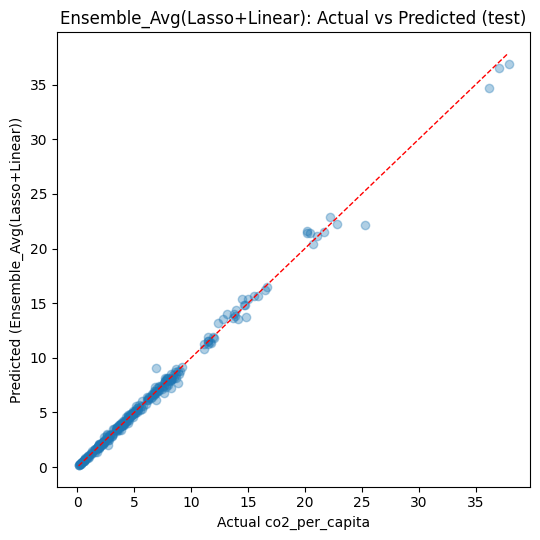

,Model,Val_RMSE,Val_MAE,Val_R2,Val_MAPE,Test_RMSE,Test_MAE,Test_R2,Test_MAPE
0,Lasso,0.340539,0.160270,0.996865,3.592337,0.376294,0.207412,0.995708,4.848228
1,Ensemble_Avg(Lasso+Linear),NaN,NaN,NaN,NaN,0.383543,0.210318,0.995541,4.850156
2,Linear,0.338854,0.165248,0.996896,3.669538,0.405592,0.223739,0.995014,5.191083
3,Ridge,0.339939,0.167396,0.996876,3.982470,0.407698,0.213303,0.994962,5.271933
4,XGBoost,0.475590,0.218470,0.993885,3.826853,0.502130,0.282905,0.992358,5.367664
5,RandomForest,0.540665,0.222113,0.992098,3.813645,0.552790,0.298929,0.990738,5.348712
6,MLP,0.495767,0.271895,0.993356,7.207119,0.583851,0.346628,0.989668,8.869332
7,PatchTST,NaN,NaN,NaN,NaN,0.901401,0.529286,0.975374,10.162910
8,TimesFM,NaN,NaN,NaN,NaN,0.947325,0.540582,0.972800,9.932686
9,LSTM,NaN,NaN,NaN,NaN,0.960029,0.544598,0.972349,13.023191


In [36]:
# --- Ensemble ---
# Pick the two models with lowest Test_RMSE among those whose predictions
# are row-aligned with y_test (length must match).
# LSTM is excluded because its predictions align with y_seq_test (different length).
n_test = len(y_test)
eligible_for_ensemble = [
    r['Model'] for r in results
    if r.get('Model') in preds
    and not r.get('_seq_only', False)
    and len(np.asarray(preds[r['Model']])) == n_test
    and np.isfinite(r.get('Test_RMSE', np.nan))
]

if len(eligible_for_ensemble) >= 2:
    # Sort by Test_RMSE to pick the actual top-2 performers.
    eligible_sorted = sorted(
        eligible_for_ensemble,
        key=lambda m: next(r['Test_RMSE'] for r in results if r['Model'] == m),
    )
    top_a, top_b = eligible_sorted[0], eligible_sorted[1]
    preds['Ensemble_Avg'] = (np.asarray(preds[top_a]) + np.asarray(preds[top_b])) / 2.0

    ens_name = f'Ensemble_Avg({top_a}+{top_b})'
    row_ens = {'Model': ens_name}
    row_ens.update({f'Val_{k}': np.nan for k in ['RMSE', 'MAE', 'R2', 'MAPE']})
    row_ens.update({f'Test_{k}': v for k, v in evaluate(y_test, preds['Ensemble_Avg']).items()})
    add_result(row_ens)

    print(f'Ensemble: {top_a} + {top_b}')
    plot_pred_vs_actual(y_test, preds['Ensemble_Avg'], ens_name, suffix='test')
else:
    print('Ensemble skipped (need at least two eligible predictions).')

# Build final table — drop internal helper column before display.
results_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in results])
results_df = results_df.sort_values('Test_RMSE', ascending=True, na_position='last').reset_index(drop=True)

results_df.to_csv(OUTPUT_DIR / 'tables' / 'r3_model_comparison.csv', index=False)
results_df


  R3 BEST SINGLE MODEL
  Model    : Lasso
  Config   : Lasso(alpha=0.001, max_iter=5000)
  Test RMSE: 0.3763
  Test MAE : 0.2074
  Test R²  : 0.9957
  Test MAPE: 4.85%

  Ensemble (Ensemble_Avg(Lasso+Linear)) does not beat best single model.



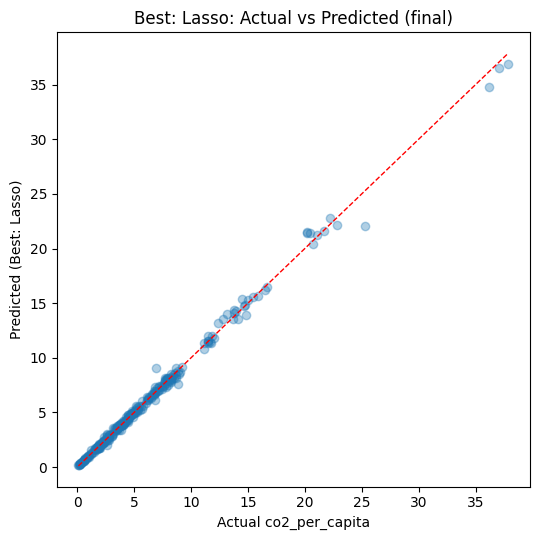

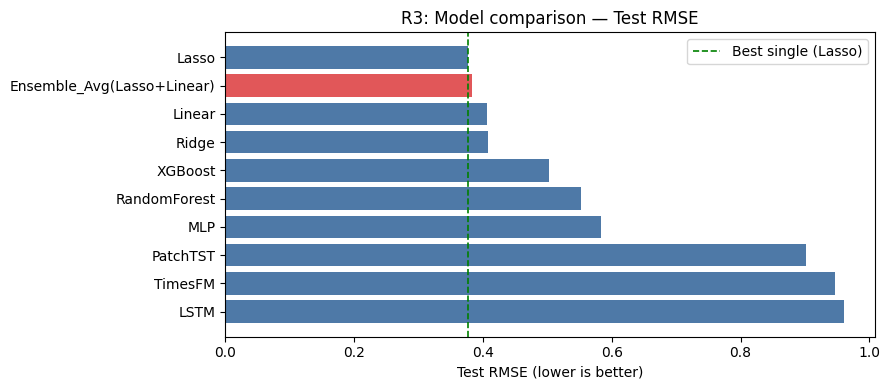

In [37]:
# ── Best model summary ───────────────────────────────────────────────────────
# Find the single model with the lowest Test_RMSE (exclude ensemble for fair
# single-model comparison, and exclude LSTM which uses a different test set).
single_models_df = results_df[~results_df['Model'].str.startswith('Ensemble')].dropna(subset=['Test_RMSE'])
best_row = single_models_df.iloc[0]
best_name = best_row['Model']

# Hyperparameter configs for each trained model — stored here for the summary.
model_configs = {
    'Linear':       'LinearRegression() — no hyperparameters',
    'Ridge':        'Ridge(alpha=1.0)',
    'Lasso':        'Lasso(alpha=0.001, max_iter=5000)',
    'RandomForest': 'RandomForestRegressor(n_estimators=400, max_depth=None, '
                    'min_samples_split=4, min_samples_leaf=2, random_state=42)',
    'XGBoost':      'XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=6, '
                    'subsample=0.9, colsample_bytree=0.8, device=cuda if CUDA else cpu)',
    'MLP':          'MLPRegressor(hidden_layer_sizes=(128,64), activation=relu, '
                    'max_iter=500, early_stopping=True, validation_fraction=0.1)',
    'LSTM':         'Keras LSTM(64) → Dense(32,relu) → Dense(1), '
                    'epochs=30, batch_size=32, val_split=0.15  [trained on TF GPU]',
    'PatchTST':     'ibm/patchtst-etth1-pretrain — zero-shot, per-country context, '
                    f'device={DEVICE}',
    'TimesFM':      'google/timesfm-1.0-200m-pytorch — zero-shot, per-country context, '
                    f'backend={"gpu" if HAS_CUDA else "cpu"}',
}

print('=' * 62)
print('  R3 BEST SINGLE MODEL')
print('=' * 62)
print(f'  Model    : {best_name}')
print(f'  Config   : {model_configs.get(best_name, "N/A")}')
print(f'  Test RMSE: {best_row["Test_RMSE"]:.4f}')
print(f'  Test MAE : {best_row["Test_MAE"]:.4f}')
print(f'  Test R²  : {best_row["Test_R2"]:.4f}')
print(f'  Test MAPE: {best_row["Test_MAPE"]:.2f}%')
print('=' * 62)

# Check if ensemble beats the best single model.
ens_rows = results_df[results_df['Model'].str.startswith('Ensemble')].dropna(subset=['Test_RMSE'])
if not ens_rows.empty:
    best_ens = ens_rows.iloc[0]
    if best_ens['Test_RMSE'] < best_row['Test_RMSE']:
        print(f'\n  Best ensemble: {best_ens["Model"]}')
        print(f'  Ensemble RMSE: {best_ens["Test_RMSE"]:.4f}  '
              f'(improvement over best single: '
              f'{best_row["Test_RMSE"] - best_ens["Test_RMSE"]:.4f})')
    else:
        print(f'\n  Ensemble ({best_ens["Model"]}) does not beat best single model.')

print()

# Final actual-vs-predicted plot for the single best model.
if best_name in preds:
    plot_pred_vs_actual(y_test, preds[best_name], f'Best: {best_name}', suffix='final')

# Bar chart comparing Test_RMSE across all models.
plot_df = results_df.dropna(subset=['Test_RMSE']).copy()
colors = ['#e15759' if 'Ensemble' in m else '#4e79a7' for m in plot_df['Model']]
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(plot_df['Model'][::-1], plot_df['Test_RMSE'][::-1], color=colors[::-1])
ax.set_xlabel('Test RMSE (lower is better)')
ax.set_title('R3: Model comparison — Test RMSE')
ax.axvline(best_row['Test_RMSE'], color='green', linestyle='--', lw=1.2, label=f'Best single ({best_name})')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'r3_model_comparison_rmse.png', dpi=150)
plt.show()
